# 02: Multivariate Anomaly Detection
## Objective
Develop a machine learning model to detect abnormal sensor patterns in real-time aquarium telemetry.

### Logic: Isolation Forest
We use the **Isolation Forest** algorithm because aquarium anomalies are rare and often consist of abnormal combinations of sensor values. This model isolates observations by randomly partitioning the feature space; anomalies are identified as points that require fewer splits (shorter path lengths) to isolate.

### Sim-to-Real Strategy
The model is validated using synthetic ground-truth labels to establish a performance baseline. This supports deployment with a pre-trained detector that can be recalibrated once real-world user feedback is collected via the dashboard.

*Note: Preprocessing is kept minimal to preserve event fidelity. Smoothing and alert persistence are handled at the application layer.*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Fixed: changed 'import sns' to 'import seaborn as sns'
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

sns.set(style="whitegrid")

In [3]:
# Load the dataset (Path assumes execution from /notebooks folder)
df = pd.read_csv("../data/smart_aquarium_dataset_v6.1.csv")

# Convert timestamp and sort to ensure temporal continuity
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

print(f"Dataset Loaded: {df.shape[0]} rows across {df.shape[1]} columns.")

Dataset Loaded: 8640 rows across 22 columns.


In [4]:
# Core sensors used for multivariate detection
feature_cols = ["temperature", "ph", "tds", "turbidity"]
label_col = "is_anomaly" # Ground truth for validation

# Isolate the modeling dataframe
df_model = df[feature_cols + [label_col]].copy()

In [5]:
# 1. Forward Fill short telemetry gaps (Packet Loss)
df_model[feature_cols] = df_model[feature_cols].ffill()

# 2. Filter physically impossible values (Hardware Failures)
# We keep outliers that are physically possible but environmentally abnormal
df_model = df_model[
    (df_model["ph"].between(0, 14)) &
    (df_model["temperature"].between(0, 45)) &
    (df_model["tds"] >= 0) &
    (df_model["turbidity"] >= 0)
].copy()

print("Preprocessing Complete.")
print(f"Missing Values:\n{df_model[feature_cols].isnull().sum()}")

Preprocessing Complete.
Missing Values:
temperature    0
ph             0
tds            0
turbidity      0
dtype: int64


In [6]:
print("--- Ground Truth Anomaly Distribution ---")
print(df_model[label_col].value_counts())
print("\nPercentage View:")
print(df_model[label_col].value_counts(normalize=True) * 100)

--- Ground Truth Anomaly Distribution ---
is_anomaly
0    8376
1     264
Name: count, dtype: int64

Percentage View:
is_anomaly
0    96.944444
1     3.055556
Name: proportion, dtype: float64


In [7]:
X = df_model[feature_cols].copy()
y_true = df_model[label_col].astype(int).copy()

print(f"Features ready: {feature_cols}")

Features ready: ['temperature', 'ph', 'tds', 'turbidity']


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization complete: Mean=0, Std=1")

Standardization complete: Mean=0, Std=1


In [16]:
# We use 200 estimators for better stability
iso_forest = IsolationForest(
    n_estimators=200, 
    contamination=0.06, 
    random_state=42
)

# Fit the model
iso_forest.fit(X_scaled)

print("Model training complete.")

Model training complete.


In [17]:
y_pred_raw = iso_forest.predict(X_scaled)

# Map: -1 -> 1 (Anomaly), 1 -> 0 (Normal)
y_pred = np.where(y_pred_raw == -1, 1, 0)

df_model["iforest_pred"] = y_pred
print(f"Model identified {y_pred.sum()} anomalous instances.")

Model identified 519 anomalous instances.


--- Isolation Forest Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      8376
           1       0.08      0.15      0.10       264

    accuracy                           0.92      8640
   macro avg       0.52      0.55      0.53      8640
weighted avg       0.94      0.92      0.93      8640



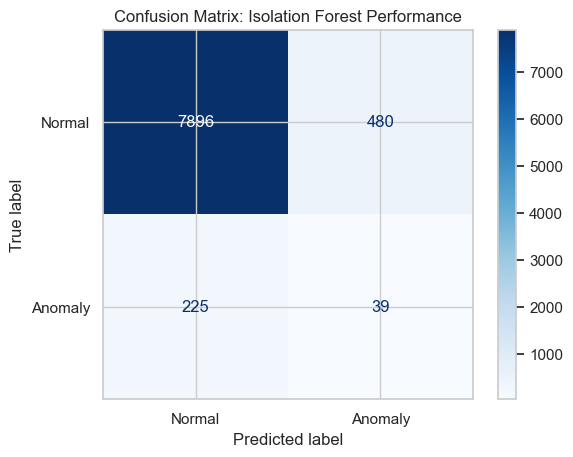

In [18]:
print("--- Isolation Forest Evaluation Metrics ---")
print(classification_report(y_true, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Isolation Forest Performance")
plt.show()

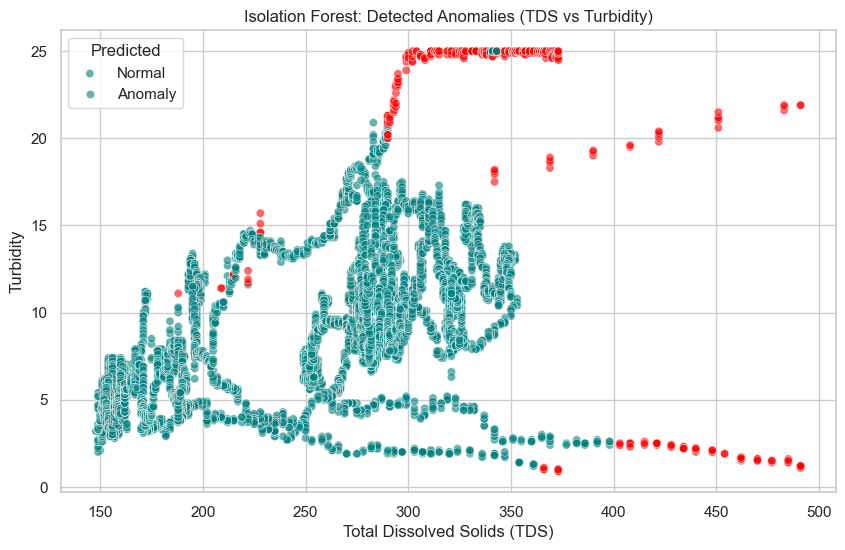

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model, 
    x='tds', 
    y='turbidity', 
    hue='iforest_pred', 
    palette={0: 'teal', 1: 'red'}, 
    alpha=0.6
)
plt.title("Isolation Forest: Detected Anomalies (TDS vs Turbidity)")
plt.xlabel("Total Dissolved Solids (TDS)")
plt.ylabel("Turbidity")
plt.legend(title="Predicted", labels=["Normal", "Anomaly"])
plt.show()

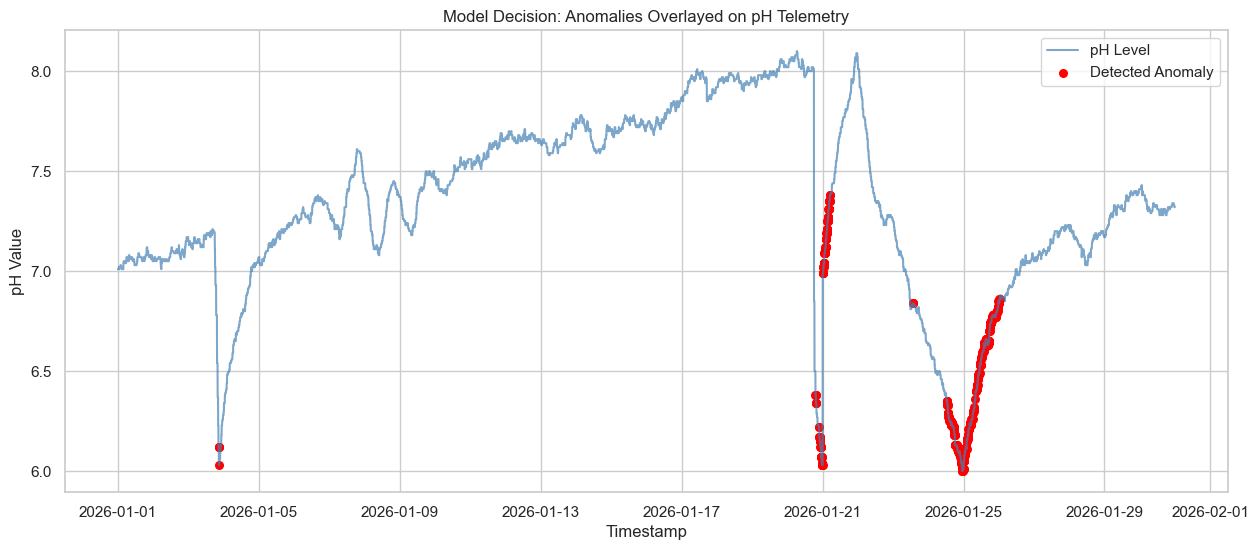

In [20]:
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model['ph'], label='pH Level', alpha=0.7, color='steelblue')

# Filter for the points the model flagged
anomalies = df_model[df_model['iforest_pred'] == 1]

# Overlay red dots
plt.scatter(anomalies.index, anomalies['ph'], color='red', label='Detected Anomaly', s=30)

plt.title("Model Decision: Anomalies Overlayed on pH Telemetry")
plt.xlabel("Timestamp")
plt.ylabel("pH Value")
plt.legend()
plt.show()

In [21]:
import joblib
import os

# Create directory
model_dir = "../models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save model
joblib.dump(iso_forest, f"{model_dir}/isolation_forest_v1.joblib")

# Save scaler
joblib.dump(scaler, f"{model_dir}/scaler_v1.joblib")

print(f"Success! Model and Scaler saved to {model_dir}")

Success! Model and Scaler saved to ../models
